In [1]:
# import os
# import sys
# from pathlib import Path
# import shutil
# import datetime
# import math

# import attrs
# from liblaf import cherries
# from loguru import logger
# from tqdm import tqdm

# # 替换此行
# # sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(__file__), "../../src")))

# # 方法1：使用当前工作目录
# notebook_dir = os.getcwd()  # 获取当前工作目录
# src_path = os.path.abspath(os.path.join(notebook_dir, "../../src"))
# sys.path.insert(0, src_path)


# import qoc
# import qoc.api as api # pyright: ignore


# db: str = qoc.data_dir("database").as_uri().replace("file://", "lmdb://")


# online: bool = False

# symbols: list[str] = [
#     "BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT", "ADAUSDT", "DOGEUSDT", "AVAXUSDT",
#     "LINKUSDT", "TRXUSDT", "DOTUSDT", "MATICUSDT", "LTCUSDT", "UNIUSDT", "ATOMUSDT", "ETCUSDT",
#     "ICPUSDT", "APTUSDT", "FILUSDT", "NEARUSDT", "HBARUSDT", "INJUSDT", "OPUSDT", "ARBUSDT",
#     "SUIUSDT", "SEIUSDT", "RENDERUSDT", "TIAUSDT", "FTMUSDT", "EGLDUSDT", "AAVEUSDT", "GALAUSDT",
#     "IMXUSDT", "PEPEUSDT", "SHIBUSDT", "FLOKIUSDT", "BONKUSDT", "WIFUSDT", "PENGUUSDT", "TRUMPUSDT",
#     "POLUSDT", "ENSUSDT", "JUPUSDT", "PYTHUSDT", "ORDIUSDT", "SATOSHIUSDT", "SATSUSDT", "MOVRUSDT",
#     "DYMUSDT", "NOTUSDT", "MAGAUSDT", "SPXUSDT"
# ]



# # symbols: list[str] = ["BTCUSDT", "DOGEUSDT"]
# transaction_fee: float = 0.01  # 交易费用为0.1%
# interval: str = "1m"
# start_date: str = "2024-09-01"
# end_date: str = "2025-08-31"
# output_dir: str = "mmpair-strategy/1m_klines_raw"


# offline_db_path = Path("mmpair-strategy")
# if offline_db_path.exists():
#     # logger.info(f"删除现有数据库文件夹: {offline_db_path}")
#     shutil.rmtree(offline_db_path)


# from offline_fetch import fetch_for_offline
# import arcticdb as adb
# uri = "lmdb://mmpair-strategy"

# ac = adb.Arctic(uri)

# qoc_library = ac.get_library('market', create_if_missing=True)

# fetch_for_offline(symbols, interval, start_date, end_date, output_dir, qoc_library)


# Preload

In [2]:
from pathlib import Path
import copy
import pandas as pd
import datetime
from datetime import datetime

output_dir = "mmpair-strategy/1m_klines_raw"
output_path = Path(output_dir)

coins_dict = {}

start_time = datetime(2024, 11, 1)
end_time = datetime(2025, 10, 31)
    
for file in output_path.iterdir():
    if file.is_file() and file.suffix.lower() == ".csv":
        df = pd.read_csv(file, encoding="utf-8")

        df["Close Time"] = df["Close Time"].apply(
            lambda x: x * 1000 + 999 if x < 2000000000000 else x
        )

        df["Close Time"] = pd.to_datetime(df["Close Time"], unit="us")

        df.columns = df.columns.str.strip().str.replace("\ufeff", "", regex=False)

        if "Close" not in df.columns or "Close Time" not in df.columns:
            print(f"⚠️ 跳过无 Close 或 Close Time 的文件: {file.name}")
            continue

        df.set_index("Close Time", inplace=True)
        symbol = file.stem.split("_")[0]
        
        if df.index.min() <= start_time:
            coins_dict[symbol] = df
            print(f"Processing symbol: {symbol}, length: {len(df)}")


chosen = [
    "BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT", "ADAUSDT", "DOGEUSDT", "AVAXUSDT",
    "LINKUSDT", "TRXUSDT",
      "DOTUSDT", "MATICUSDT", "LTCUSDT", "UNIUSDT", "ATOMUSDT", "ETCUSDT",
    "ICPUSDT", "APTUSDT", "FILUSDT", "NEARUSDT", "HBARUSDT", "INJUSDT", "OPUSDT", "ARBUSDT",
    "SUIUSDT", "SEIUSDT", "RENDERUSDT", "TIAUSDT", "FTMUSDT", "EGLDUSDT", "AAVEUSDT", "GALAUSDT",
    "IMXUSDT", "PEPEUSDT", "SHIBUSDT", "FLOKIUSDT", "BONKUSDT", "WIFUSDT", "PENGUUSDT", "TRUMPUSDT",
    "POLUSDT", "ENSUSDT", "JUPUSDT", "PYTHUSDT", "ORDIUSDT", "SATOSHIUSDT", "SATSUSDT", "MOVRUSDT",
    "DYMUSDT", "NOTUSDT", "MAGAUSDT", "SPXUSDT"
]

hedge_list = {k: v for k, v in coins_dict.items() if k in chosen}


temp = copy.copy(hedge_list)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  File "/opt/anaconda3/lib/python3.12/site-

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  File "/opt/anaconda3/lib/python3.12/site-

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Processing symbol: IMXUSDT, length: 1140480
Processing symbol: SOLUSDT, length: 1140480
Processing symbol: SOLUSDT, length: 1140480
Processing symbol: NOTUSDT, length: 768240
Processing symbol: NOTUSDT, length: 768240
Processing symbol: BONKUSDT, length: 988800
Processing symbol: BONKUSDT, length: 988800
Processing symbol: LTCUSDT, length: 1140480
Processing symbol: LTCUSDT, length: 1140480
Processing symbol: ORDIUSDT, length: 1043280
Processing symbol: ORDIUSDT, length: 1043280
Processing symbol: SUIUSDT, length: 1140480
Processing symbol: SUIUSDT, length: 1140480
Processing symbol: POLUSDT, length: 595560
Processing symbol: POLUSDT, length: 595560
Processing symbol: JUPUSDT, length: 920640
Processing symbol: JUPUSDT, length: 920640
Processing symbol: NEARUSDT, length: 1140480
Processing symbol: NEARUSDT, length: 1140480
Processing symbol: ATOMUSDT, length: 1140480
Processing symbol: ATOMUSDT, length: 1140480
Processing symbol: APTUSDT, length: 1140480
Processing symbol: APTUSDT, leng

In [3]:
hedge_list = temp

In [4]:

import numpy as np
from scipy.optimize import linprog
import matplotlib.pyplot as plt
from collections import deque
from sklearn.linear_model import LinearRegression
from tqdm import tqdm
import random
import os


In [5]:
len(hedge_list.keys())

46

In [6]:
for symbol, df in hedge_list.items():
    print(df.index.min(), df.index.max())
    hedge_list[symbol] = df[(df.index >= start_time) & (df.index <= end_time)]

2023-09-01 00:00:59.999999 2025-10-31 23:59:59.999999
2023-09-01 00:00:59.999999 2025-10-31 23:59:59.999999
2023-09-01 00:00:59.999999 2025-10-31 23:59:59.999999
2024-05-16 12:00:59.999999 2025-10-31 23:59:59.999999
2024-05-16 12:00:59.999999 2025-10-31 23:59:59.999999
2023-12-15 08:00:59.999999 2025-10-31 23:59:59.999999
2023-12-15 08:00:59.999999 2025-10-31 23:59:59.999999
2023-09-01 00:00:59.999999 2025-10-31 23:59:59.999999
2023-09-01 00:00:59.999999 2025-10-31 23:59:59.999999
2023-11-07 12:00:59.999999 2025-10-31 23:59:59.999999
2023-11-07 12:00:59.999999 2025-10-31 23:59:59.999999
2023-09-01 00:00:59.999999 2025-10-31 23:59:59.999999
2023-09-01 00:00:59.999999 2025-10-31 23:59:59.999999
2024-09-13 10:00:59.999999 2025-10-31 23:59:59.999999
2024-09-13 10:00:59.999999 2025-10-31 23:59:59.999999
2024-01-31 16:00:59.999999 2025-10-31 23:59:59.999999
2024-01-31 16:00:59.999999 2025-10-31 23:59:59.999999
2023-09-01 00:00:59.999999 2025-10-31 23:59:59.999999
2023-09-01 00:00:59.999999 2

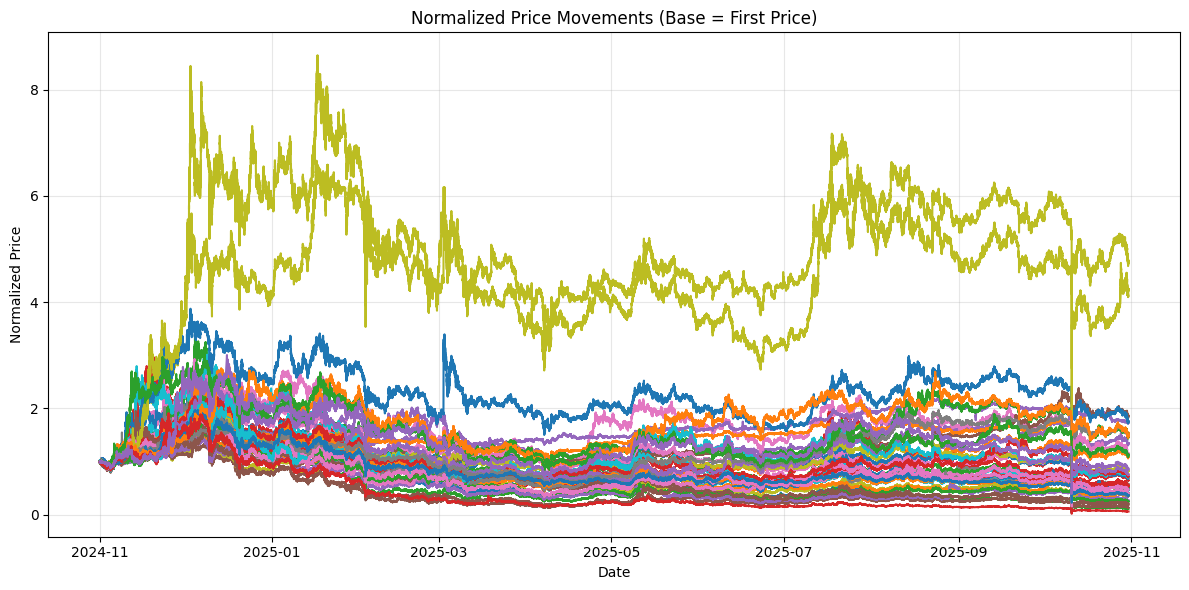

In [7]:
plt.figure(figsize=(12, 6))
for symbol, df in hedge_list.items():
    if len(df) > 0:  # Check if dataframe is not empty
        # Normalize to first price
        normalized_prices = df["Close"] / df["Close"].iloc[0]
        plt.plot(df.index, normalized_prices, label=symbol)

plt.title('Normalized Price Movements (Base = First Price)')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

## Para

In [17]:

FORWARD_WINDOW = 60
BACK_WINDOW = 120
BULLET_SIZE = 50

# Stats

## AMIHUD

In [18]:
amihud_window = BACK_WINDOW
for symbol, df in hedge_list.items():
    df["Close_x_Volume"] = df["Close"] * df["Volume"]
    df["Amihud"] = df["Close_x_Volume"].diff().abs()/df["Close_x_Volume"].rolling(window=amihud_window).mean() 
    df.dropna(inplace=True)   

/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_32329/3147095631.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Close_x_Volume"] = df["Close"] * df["Volume"]
/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_32329/3147095631.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Amihud"] = df["Close_x_Volume"].diff().abs()/df["Close_x_Volume"].rolling(window=amihud_window).mean()
/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_32329/3147095631.py:5: SettingWithCopyWa

## Split

In [43]:
# Remove MATICUSDT from hedge_list

if 'MATICUSDT' in hedge_list:
    del hedge_list['MATICUSDT']
    print("MATICUSDT removed from hedge_list")
else:
    print("MATICUSDT not found in hedge_list")

print(f"Remaining symbols in hedge_list: {list(hedge_list.keys())}")

if 'FTMUSDT' in hedge_list:
    del hedge_list['FTMUSDT']
    print("FTMUSDT removed from hedge_list")
else:
    print("FTMUSDT not found in hedge_list")

print(f"Remaining symbols in hedge_list: {list(hedge_list.keys())}")

MATICUSDT removed from hedge_list
Remaining symbols in hedge_list: ['IMXUSDT', 'SOLUSDT', 'NOTUSDT', 'BONKUSDT', 'LTCUSDT', 'ORDIUSDT', 'SUIUSDT', 'POLUSDT', 'JUPUSDT', 'NEARUSDT', 'ATOMUSDT', 'APTUSDT', 'GALAUSDT', 'ARBUSDT', 'TRXUSDT', 'BNBUSDT', 'DOTUSDT', 'FILUSDT', 'ETCUSDT', 'RENDERUSDT', 'FLOKIUSDT', 'BTCUSDT', 'LINKUSDT', 'SHIBUSDT', 'PYTHUSDT', 'TIAUSDT', 'SEIUSDT', 'MOVRUSDT', 'XRPUSDT', 'PEPEUSDT', 'ADAUSDT', 'EGLDUSDT', 'OPUSDT', 'AVAXUSDT', 'UNIUSDT', 'WIFUSDT', 'INJUSDT', 'ETHUSDT', 'HBARUSDT', 'FTMUSDT', 'ICPUSDT', 'AAVEUSDT', 'DOGEUSDT', 'DYMUSDT', 'ENSUSDT']
FTMUSDT removed from hedge_list
Remaining symbols in hedge_list: ['IMXUSDT', 'SOLUSDT', 'NOTUSDT', 'BONKUSDT', 'LTCUSDT', 'ORDIUSDT', 'SUIUSDT', 'POLUSDT', 'JUPUSDT', 'NEARUSDT', 'ATOMUSDT', 'APTUSDT', 'GALAUSDT', 'ARBUSDT', 'TRXUSDT', 'BNBUSDT', 'DOTUSDT', 'FILUSDT', 'ETCUSDT', 'RENDERUSDT', 'FLOKIUSDT', 'BTCUSDT', 'LINKUSDT', 'SHIBUSDT', 'PYTHUSDT', 'TIAUSDT', 'SEIUSDT', 'MOVRUSDT', 'XRPUSDT', 'PEPEUSDT', 'ADAUSD

In [44]:
split_date = datetime(2025, 7, 1)

train_list = {}
test_list = {}

for symbol, df in hedge_list.items():
    train_list[symbol] = df[df.index < split_date]
    test_list[symbol] = df[df.index >= split_date]

## Regress

In [45]:

back_window = BACK_WINDOW
forward_window = FORWARD_WINDOW
bullet_size = BULLET_SIZE


# btc_close = deque(btc['Close'][:back_window], maxlen=back_window)
coin_closes = {name: deque(df['Close'][:back_window], maxlen=back_window) for name, df in hedge_list.items()}


# btc_volume = deque(btc['Volume'][:back_window], maxlen=back_window)
coin_volumes = {name: deque(df['Volume'][:back_window], maxlen=back_window) for name, df in hedge_list.items()}


xy_1 = {name: deque(np.array([0]*back_window), maxlen=back_window) for name in hedge_list.keys()}
xx_1 = {name: deque(np.array([0]*back_window), maxlen=back_window) for name in hedge_list.keys()}
yy_1 = {name: deque(np.array([0]*back_window), maxlen=back_window) for name in hedge_list.keys()}
x_1 = {name: deque(np.array([0]*back_window), maxlen=back_window) for name in hedge_list.keys()}
y_1 = {name: deque(np.array([0]*back_window), maxlen=back_window) for name in hedge_list.keys()}


xy_1_sum = {name: 0 for name in hedge_list.keys()}
xx_1_sum = {name: 0 for name in hedge_list.keys()}
yy_1_sum = {name: 0 for name in hedge_list.keys()}
x_1_sum = {name: 0 for name in hedge_list.keys()}
y_1_sum = {name: 0 for name in hedge_list.keys()}

# Trade

In [194]:
data_list = train_list

# Create common index from intersection of all dataframes
common_index = None
for symbol, df in data_list.items():
    if common_index is None:
        common_index = df.index
        print(f"Initial common index length from {symbol}: {len(common_index)}")
    else:
        common_index = common_index.intersection(df.index)
        print(f"After processing {symbol}, common index length: {len(common_index)}")

print(f"Common index length: {len(common_index)}")
print(f"Date range: {common_index.min()} to {common_index.max()}")

Initial common index length from IMXUSDT: 348242
After processing SOLUSDT, common index length: 348242
After processing NOTUSDT, common index length: 348242
After processing BONKUSDT, common index length: 348242
After processing LTCUSDT, common index length: 348242
After processing ORDIUSDT, common index length: 348242
After processing SUIUSDT, common index length: 348242
After processing POLUSDT, common index length: 348242
After processing JUPUSDT, common index length: 348242
After processing NEARUSDT, common index length: 348242
After processing ATOMUSDT, common index length: 348242
After processing APTUSDT, common index length: 348242
After processing GALAUSDT, common index length: 348242
After processing ARBUSDT, common index length: 348242
After processing TRXUSDT, common index length: 348242
After processing BNBUSDT, common index length: 348242
After processing DOTUSDT, common index length: 348242
After processing FILUSDT, common index length: 348242
After processing ETCUSDT, co

In [ ]:
# Initialize coef_records
coef_records = {}

revenues = []
stats_1 = []
stats_2 = []
stats_3 = []




for i, t in tqdm(enumerate(common_index), desc="Processing timestamps", total=len(common_index)):
    # Only access data if timestamp exists in all dataframes
    for name, df in hedge_list.items():
        if t in df.index:
            coin_closes[name].append(df.loc[t, "Close"])
            coin_volumes[name].append(df.loc[t, "Volume"])
        else:
            print(f"Timestamp {t} not found in {name}, skipping...")
            continue

    if i>=back_window:
        for name, _ in hedge_list.items():
            if t not in hedge_list[name].index:
                continue
                
            # growth = (np.array(coin_closes[name])[-1] - np.array(coin_closes[name])[-2]) 
            # mkt_idx_diff = coin_closes['BTCUSDT'][-1] - coin_closes['BTCUSDT'][-2]                
            growth = (np.array(coin_closes[name])[-1]) 
            mkt_idx_diff = coin_closes['BTCUSDT'][-1]
            if len(xy_1[name])>=back_window:
                xy_1_sum[name] -= xy_1[name][0]
                xx_1_sum[name] -= xx_1[name][0]
                yy_1_sum[name] -= yy_1[name][0]
                x_1_sum[name] -= x_1[name][0]
                y_1_sum[name] -= y_1[name][0]

            xy_1[name].append(growth*mkt_idx_diff)
            xx_1[name].append(mkt_idx_diff**2)
            yy_1[name].append(growth**2)
            x_1[name].append(mkt_idx_diff)
            y_1[name].append(growth)
            
            xy_1_sum[name] += xy_1[name][-1]
            xx_1_sum[name] += xx_1[name][-1]
            yy_1_sum[name] += yy_1[name][-1]
            x_1_sum[name] += x_1[name][-1]
            y_1_sum[name] += y_1[name][-1]
            
            if i >= 2*back_window:
                # Without intercept
                coef_1 = xy_1_sum[name]/xx_1_sum[name]*1000 if xx_1_sum[name]!=0 else 0
                residual = np.array(coin_closes[name])[-1] - (coef_1/1000 * (np.array(coin_closes['BTCUSDT'])[-1]))

                # With intercept
                beta = 1000*(back_window * xy_1_sum[name] - x_1_sum[name]*y_1_sum[name]) / (back_window * xx_1_sum[name] - x_1_sum[name]**2) if (back_window * xx_1_sum[name] - x_1_sum[name]**2) != 0 else 0
                alpha = (y_1_sum[name] - beta * x_1_sum[name]) / back_window if back_window != 0 else 0
                residual = np.array(coin_closes[name])[-1] - (beta/1000 * np.array(coin_closes['BTCUSDT'])[-1] + alpha)

                corr_1 = (back_window * xy_1_sum[name] - x_1_sum[name]*y_1_sum[name]) / np.sqrt((back_window*xx_1_sum[name]-x_1_sum[name]**2)*(back_window*yy_1_sum[name]-y_1_sum[name]**2)) if (back_window*xx_1_sum[name]-x_1_sum[name]**2)*(back_window*yy_1_sum[name]-y_1_sum[name]**2) >0 else 0
                amihud = hedge_list[name].loc[t, "Amihud"]
                coef_records[name] = {
                    'Close': hedge_list[name].loc[t, "Close"],
                    'coef_1': coef_1,
                    'corr_1': corr_1,
                    'amihud': amihud,
                    'residual': residual/coef_1 if coef_1 != 0 else 0,
                }

        if i >= 2*back_window and len(coef_records) > 1:
            coef_df = pd.DataFrame.from_dict(coef_records, orient='index')  # index=coin
            
            # Select coins based on residual values
            long_coin = coef_df.sort_values(by='residual', ascending=True).index[0]
            short_coin = coef_df.sort_values(by='residual', ascending=False).index[0]

            future_long_price = data_list[long_coin].loc[common_index[i + forward_window], "Close"] if (i + forward_window) < len(common_index) else price_long_now
            future_short_price = data_list[short_coin].loc[common_index[i + forward_window], "Close"] if (i + forward_window) < len(common_index) else price_short_now

            price_long_now = coef_df.loc[long_coin, 'Close']
            price_short_now = coef_df.loc[short_coin, 'Close']

            price_long_fut = future_long_price
            price_short_fut = future_short_price

            coef_1_long = coef_df.loc[long_coin, 'coef_1']
            coef_1_short = coef_df.loc[short_coin, 'coef_1']

            x_l = coef_1_short*bullet_size/(coef_1_long*price_short_now + coef_1_short*price_long_now)
            x_s = coef_1_long*bullet_size/(coef_1_long*price_short_now + coef_1_short*price_long_now)

            revenue = x_l * (price_long_fut - price_long_now) - x_s * (price_short_fut - price_short_now)

            amihud_2 = (coef_df.loc[long_coin, 'amihud'] + coef_df.loc[short_coin, 'amihud']) / 2

            amihud_all = coef_df['amihud'].mean()

            stats_1.append(amihud_2)
            stats_2.append(amihud_all)
            stat_3 = coef_df.loc[short_coin, 'residual']-coef_df.loc[long_coin, 'residual']
            stats_3.append(stat_3)
            if stat_3 > 5:
                revenues.append(revenue)
            else:
                revenues.append(0)
            

            
            if i % 6666 == 0:
                revenue_series = pd.Series(revenues)
                cumulative_revenue = np.cumsum(revenue_series)
                fig = plt.figure(figsize=(10, 6))
                plt.plot(cumulative_revenue)
                plt.xlabel("Trades")
                plt.ylabel("Cumulative Revenue")
                plt.title("Cumulative Revenue over Trades")
                plt.savefig("cumulative_revenue.png", dpi=300)
                plt.close(fig)






Processing timestamps:  76%|███████▌  | 264984/348242 [12:22<04:13, 328.95it/s]  

In [ ]:
revenue_series = pd.Series(revenues)
stats_1_series = pd.Series(stats_1)
stats_2_series = pd.Series(stats_2)
stats_3_series = pd.Series(stats_3)

revenue_series.to_csv("revenue_series.csv", index=False)
stats_1_series.to_csv("stats_1_series.csv", index=False)
stats_2_series.to_csv("stats_2_series.csv", index=False)
stats_3_series.to_csv("stats_3_series.csv", index=False)


In [ ]:
revenue_series = pd.read_csv("revenue_series.csv", header=None).squeeze()
stats_1_series = pd.read_csv("stats_1_series.csv", header=None).squeeze()
stats_2_series = pd.read_csv("stats_2_series.csv", header=None).squeeze()
stats_3_series = pd.read_csv("stats_3_series.csv", header=None).squeeze()

In [ ]:
revenue_series.max(), revenue_series.min(), revenue_series.mean(), revenue_series.std()

(np.float64(4.881938039671719),
 np.float64(-9.72541912456747),
 np.float64(0.0013476794176883167),
 np.float64(0.2980660512433831))

In [ ]:
min_value_index = revenue_series.idxmin()
min_value = revenue_series.min()

print(f"The minimum value in revenue_series is {min_value} at index {min_value_index}.")

The minimum value in revenue_series is -9.72541912456747 at index 174692.


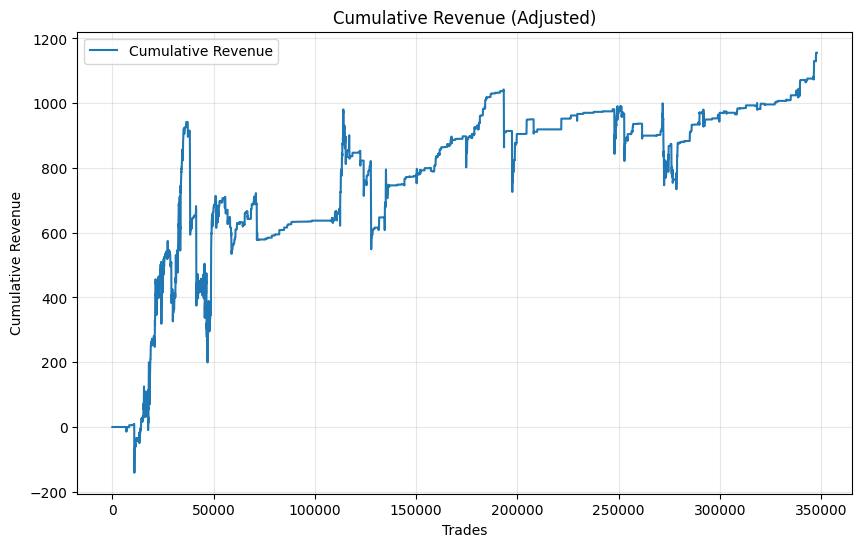

In [ ]:
# 将 revenue_series 大于 50 的值设置为 20，小于等于 50 的值设置为 -20
adjusted_revenue_series = revenue_series.apply(lambda x: 1 if x > 5 else x)
adjusted_revenue_series = adjusted_revenue_series.apply(lambda x: -1 if x < -5 else x)

# 计算累积收益
cumulative_revenue = np.cumsum(adjusted_revenue_series)

# 绘制累积收益图
plt.figure(figsize=(10, 6))
plt.plot(cumulative_revenue, label="Cumulative Revenue")
plt.xlabel("Trades")
plt.ylabel("Cumulative Revenue")
plt.title("Cumulative Revenue (Adjusted)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
non_zero_revenue = [r for r in adjusted_revenue_series if r != 0]
non_zero_revenue = pd.Series(non_zero_revenue)
print(non_zero_revenue.mean(), non_zero_revenue.std())

non_zero_index = non_zero_revenue.index.tolist()

non_zero_stats_1 = stats_1_series[non_zero_index]
non_zero_stats_2 = stats_2_series[non_zero_index]
non_zero_stats_3 = stats_3_series[non_zero_index]

0.04684668391393193 1.0211747746751947


/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_32329/203313985.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df.groupby("bin")["revenue"].agg(


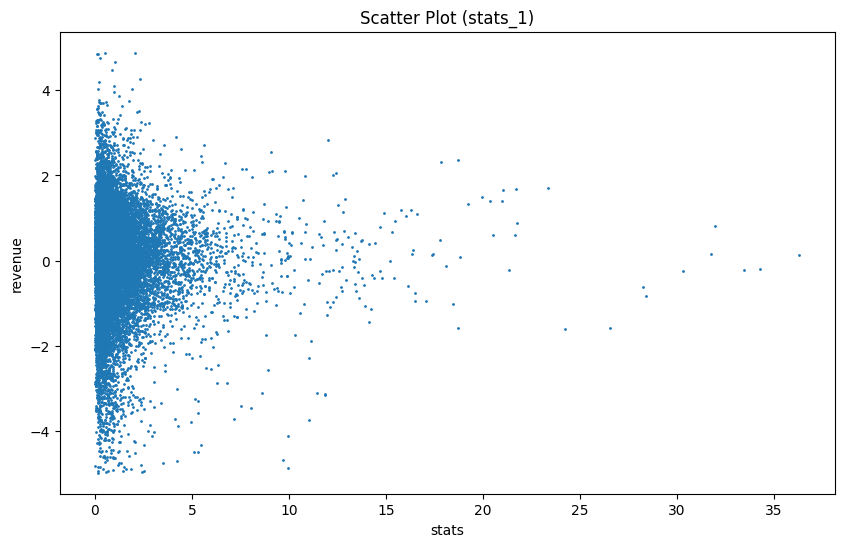

<Figure size 1200x600 with 0 Axes>

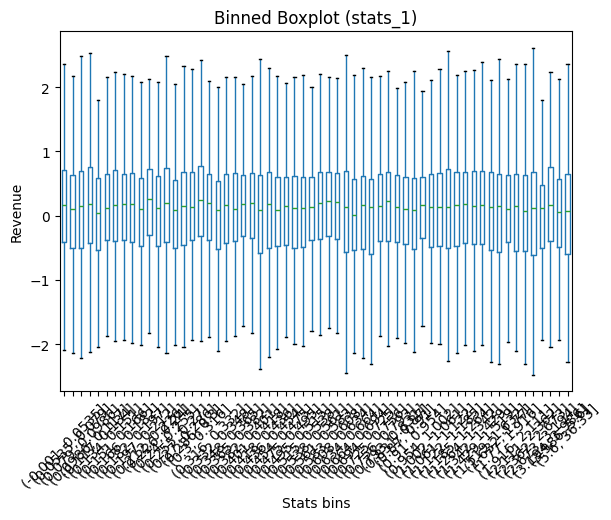

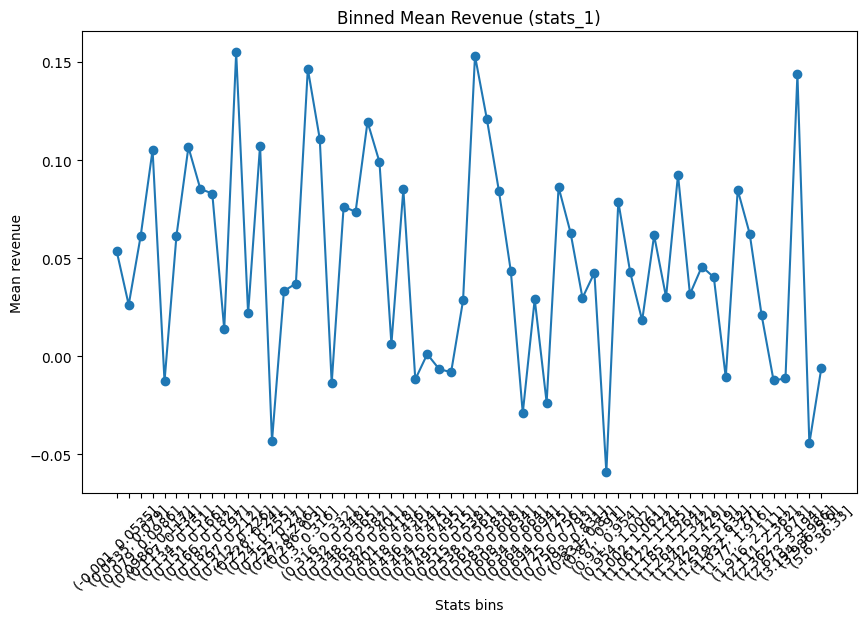


Summary statistics for stats_1:
                  count      mean    median       std
bin                                                  
(-0.001, 0.0535]    412  0.053441  0.161644  1.009412
(0.0535, 0.079]     411  0.026230  0.109096  1.002226
(0.079, 0.0986]     411  0.061219  0.149260  1.025886
(0.0986, 0.117]     412  0.105192  0.182181  1.029011
(0.117, 0.134]      411 -0.012819  0.042050  0.939145
(0.134, 0.151]      411  0.061431  0.113499  1.036378
(0.151, 0.166]      411  0.106633  0.166942  1.083222
(0.166, 0.182]      412  0.085332  0.186049  1.057596
(0.182, 0.197]      411  0.082981  0.184977  0.943711
(0.197, 0.212]      411  0.013734  0.107856  1.021461
(0.212, 0.226]      411  0.154926  0.257746  0.964412
(0.226, 0.24]       412  0.021850  0.117982  0.956232
(0.24, 0.255]       411  0.107465  0.199242  1.174000
(0.255, 0.27]       411 -0.043236  0.090323  1.079676
(0.27, 0.286]       411  0.033266  0.144061  0.995334
(0.286, 0.3]        412  0.037080  0.138831  0.98

/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_32329/203313985.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df.groupby("bin")["revenue"].agg(


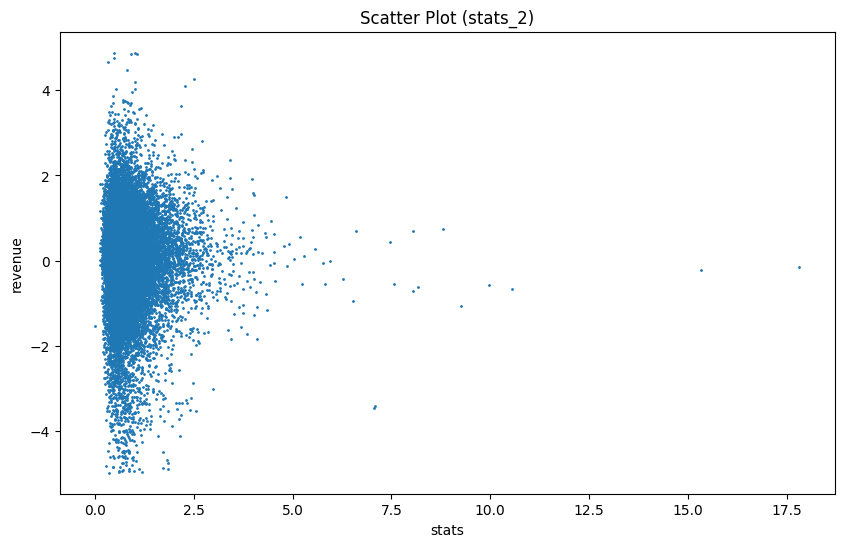

<Figure size 1200x600 with 0 Axes>

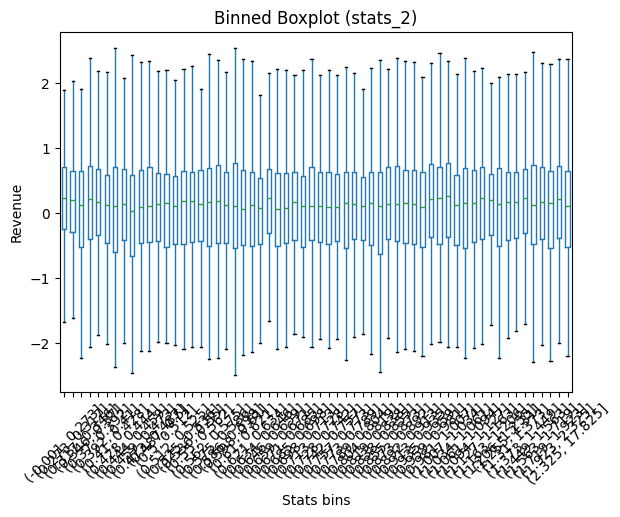

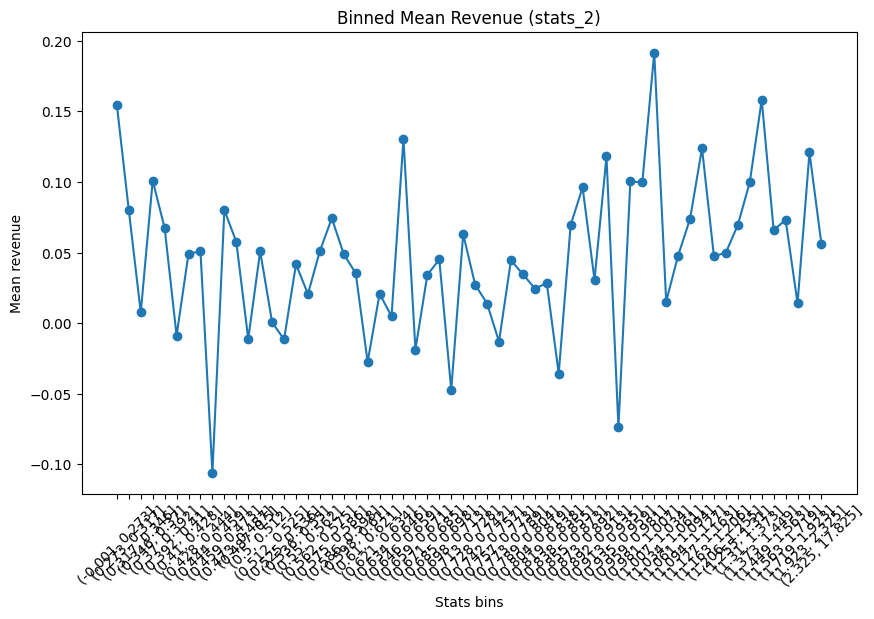


Summary statistics for stats_2:
                 count      mean    median       std
bin                                                 
(-0.001, 0.273]    412  0.154406  0.221899  0.903688
(0.273, 0.317]     411  0.079895  0.200955  0.959252
(0.317, 0.346]     411  0.007595  0.115625  0.991723
(0.346, 0.37]      412  0.100952  0.219116  1.030969
(0.37, 0.392]      411  0.067361  0.167989  1.020616
(0.392, 0.41]      411 -0.008845  0.124899  1.025296
(0.41, 0.428]      411  0.049267  0.101631  1.039315
(0.428, 0.444]     412  0.050748  0.140965  1.009463
(0.444, 0.459]     411 -0.106029  0.031331  1.108854
(0.459, 0.473]     411  0.080180  0.086241  1.101083
(0.473, 0.487]     411  0.057546  0.107754  1.041560
(0.487, 0.5]       412 -0.011144  0.130349  1.068383
(0.5, 0.512]       411  0.050922  0.149126  1.038770
(0.512, 0.525]     411  0.000582  0.103951  0.937073
(0.525, 0.536]     411 -0.011551  0.180811  1.027149
(0.536, 0.55]      412  0.041700  0.176594  1.036961
(0.55, 0.562]

/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_32329/203313985.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df.groupby("bin")["revenue"].agg(


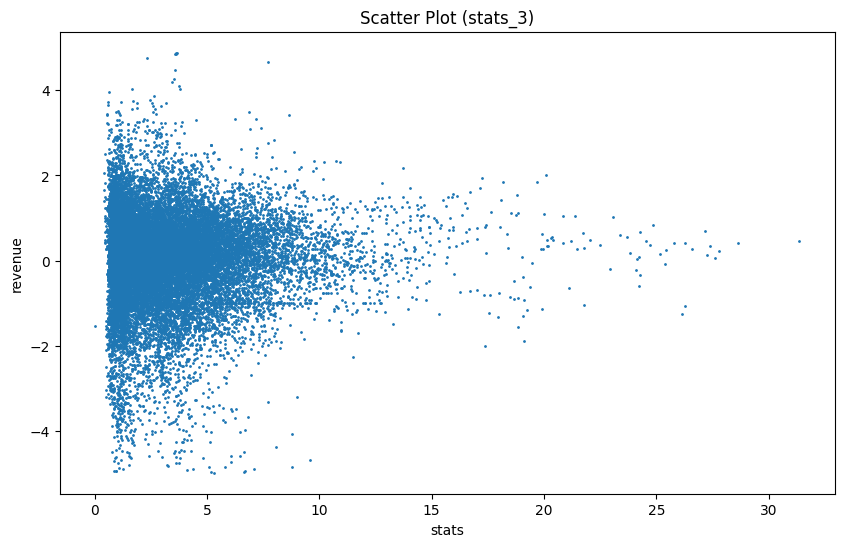

<Figure size 1200x600 with 0 Axes>

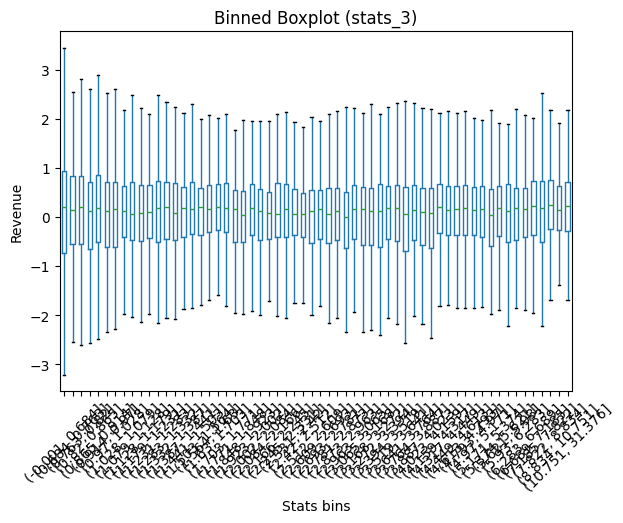

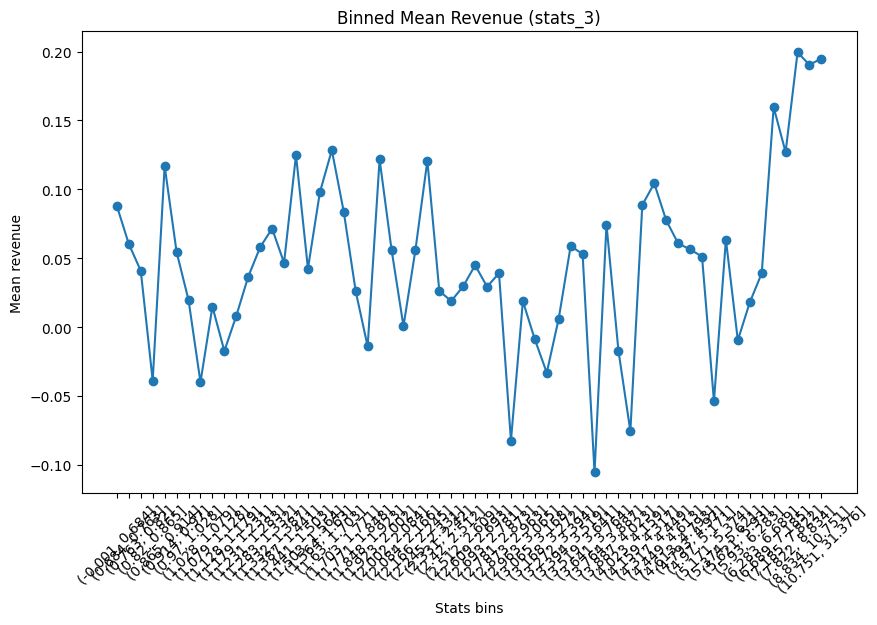


Summary statistics for stats_3:
                  count      mean    median       std
bin                                                  
(-0.001, 0.684]     412  0.087918  0.195944  1.322795
(0.684, 0.763]      411  0.060330  0.143460  1.176692
(0.763, 0.82]       411  0.040963  0.211940  1.130263
(0.82, 0.865]       412 -0.038815  0.128393  1.193662
(0.865, 0.914]      411  0.117005  0.179042  1.071893
(0.914, 0.97]       411  0.054580  0.115806  1.188915
(0.97, 1.028]       411  0.019729  0.152752  1.201120
(1.028, 1.079]      412 -0.039952  0.113788  1.157667
(1.079, 1.128]      411  0.014914  0.055813  1.220700
(1.128, 1.179]      411 -0.017329  0.074806  1.209384
(1.179, 1.231]      411  0.008235  0.106952  1.132134
(1.231, 1.283]      412  0.036657  0.190016  1.080129
(1.283, 1.332]      411  0.058100  0.200653  1.043881
(1.332, 1.387]      411  0.071523  0.087238  0.979715
(1.387, 1.441]      411  0.046675  0.179032  1.019743
(1.441, 1.503]      412  0.124881  0.168896  1.05

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

n_bins = 60  # 分箱数量，可调整

for i, stats in enumerate([
non_zero_stats_1,non_zero_stats_2,non_zero_stats_3], start=1):

    df = pd.DataFrame({
        "stats": stats,
        "revenue": non_zero_revenue
    }).dropna()

    # 等频分箱（推荐用于分布不均）
    df["bin"] = pd.qcut(df["stats"], q=n_bins, duplicates="drop")

    # 分箱统计
    bin_stats = df.groupby("bin")["revenue"].agg(
        count="count",
        mean="mean",
        median="median",
        std="std"
    )

    # ===== 1. 原始散点图 =====
    plt.figure(figsize=(10, 6))
    plt.scatter(df["stats"], df["revenue"], s=1)
    plt.xlabel("stats")
    plt.ylabel("revenue")
    plt.title(f"Scatter Plot (stats_{i})")
    plt.show()
    plt.close()

    # ===== 2. 分箱箱线图 =====
    plt.figure(figsize=(12, 6))
    df.boxplot(
        column="revenue",
        by="bin",
        showfliers=False,
        grid=False
    )
    plt.xticks(rotation=45)
    plt.xlabel("Stats bins")
    plt.ylabel("Revenue")
    plt.title(f"Binned Boxplot (stats_{i})")
    plt.suptitle("")
    plt.show()
    plt.close()

    # ===== 3. 分箱均值曲线 =====
    plt.figure(figsize=(10, 6))
    plt.plot(
        range(len(bin_stats)),
        bin_stats["mean"].values,
        marker="o"
    )
    plt.xticks(range(len(bin_stats)), bin_stats.index.astype(str), rotation=45)
    plt.xlabel("Stats bins")
    plt.ylabel("Mean revenue")
    plt.title(f"Binned Mean Revenue (stats_{i})")
    plt.show()
    plt.close()

    # ===== 4. 输出统计表 =====
    print(f"\nSummary statistics for stats_{i}:")
    print(bin_stats)


In [ ]:
all_trades = pd.DataFrame({
    "revenue": stat_3,
    "stats_1": stats_1_series,
    "stats_2": stats_2_series,
    "stats_3": stats_3_series
})